In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/jena_climate_2009_2016.csv')

In [ ]:
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20623 entries, 0 to 20622
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date Time        20623 non-null  object 
 1   p (mbar)         20623 non-null  float64
 2   T (degC)         20623 non-null  float64
 3   Tpot (K)         20622 non-null  float64
 4   Tdew (degC)      20622 non-null  float64
 5   rh (%)           20622 non-null  float64
 6   VPmax (mbar)     20622 non-null  float64
 7   VPact (mbar)     20622 non-null  float64
 8   VPdef (mbar)     20622 non-null  float64
 9   sh (g/kg)        20622 non-null  float64
 10  H2OC (mmol/mol)  20622 non-null  float64
 11  rho (g/m**3)     20622 non-null  float64
 12  wv (m/s)         20622 non-null  float64
 13  max. wv (m/s)    20622 non-null  float64
 14  wd (deg)         20622 non-null  float64
dtypes: float64(14), object(1)
memory usage: 2.4+ MB


**discovering nulls and filling it**

In [ ]:
df.isna().sum()

,0
Date Time,0
p (mbar),0
T (degC),0
Tpot (K),1
Tdew (degC),1
rh (%),1
VPmax (mbar),1
VPact (mbar),1
VPdef (mbar),1
sh (g/kg),1


In [ ]:
df = df.interpolate()
#as our data has nulls between small gaps so that we can filling with interpolation safely

/tmp/ipython-input-4248604237.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate()


In [ ]:
df.isnull().sum()

,0
Date Time,0
p (mbar),0
T (degC),0
Tpot (K),0
Tdew (degC),0
rh (%),0
VPmax (mbar),0
VPact (mbar),0
VPdef (mbar),0
sh (g/kg),0


# **feature engineering (circular encoding)**

In [ ]:
#adapting data types to be in date time format
df['Date Time'] = pd.to_datetime(df['Date Time'] , format='mixed')
df = df.set_index('Date Time')


In [ ]:
# This part is for showing the hours that doesn't exist in the original dataset
# Where pandas create rows for these hours even they don't exist in the orignal dataset
counts = df.resample("1H").count()
counts[counts == 0].dropna(how="all")


/tmp/ipython-input-772640908.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  counts = df.resample("1H").count()


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-06 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2009-01-06 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2009-01-06 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2009-01-06 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2009-01-06 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2009-11-30 19:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2009-11-30 20:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2009-11-30 21:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:

#1- resampling data to be hourly instead of 10 min interval
df_hourly = df.resample('1H').mean().reset_index()

/tmp/ipython-input-3356482445.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('1H').mean().reset_index()


In [ ]:
#2- adding col hour , month but using the sin and cos as i want the cyclicity means in month (1 - 12 )are adjecents
# extracting raw hour and month integers
df_hourly['hour'] = df_hourly['Date Time'].dt.hour

#For Hour (Max Value = 24)
hours_in_day = 24
df_hourly['hour_sin'] = np.sin(df_hourly['hour'] * (2. * np.pi / hours_in_day))
df_hourly['hour_cos'] = np.cos(df_hourly['hour'] * (2. * np.pi / hours_in_day))

#MODIFICATION_2
#Seasonal cycle (day of year - more precise than month)
df_hourly['day_of_year'] = df_hourly['Date Time'].dt.dayofyear
df_hourly['doy_sin'] = np.sin(2*np.pi*df_hourly['day_of_year']/365.25)
df_hourly['doy_cos'] = np.cos(2*np.pi*df_hourly['day_of_year']/365.25)


In [ ]:
df_hourly.isnull().sum()

,0
Date Time,0
p (mbar),4698
T (degC),4698
Tpot (K),4698
Tdew (degC),4698
rh (%),4698
VPmax (mbar),4698
VPact (mbar),4698
VPdef (mbar),4698
sh (g/kg),4698


In [ ]:
df_hourly = df_hourly.interpolate()


In [ ]:
df_hourly.isnull().sum().sum()

np.int64(0)

In [ ]:
df.head(10)

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
2009-01-01 01:00:00,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
2009-01-01 01:10:00,996.50,-7.62,265.81,-8.30,94.8,3.44,3.26,0.18,2.04,3.27,1305.68,0.18,0.63,166.5
2009-01-01 01:20:00,996.50,-7.62,265.81,-8.36,94.4,3.44,3.25,0.19,2.03,3.26,1305.69,0.19,0.50,118.6
2009-01-01 01:30:00,996.50,-7.91,265.52,-8.73,93.8,3.36,3.15,0.21,1.97,3.16,1307.17,0.28,0.75,188.5


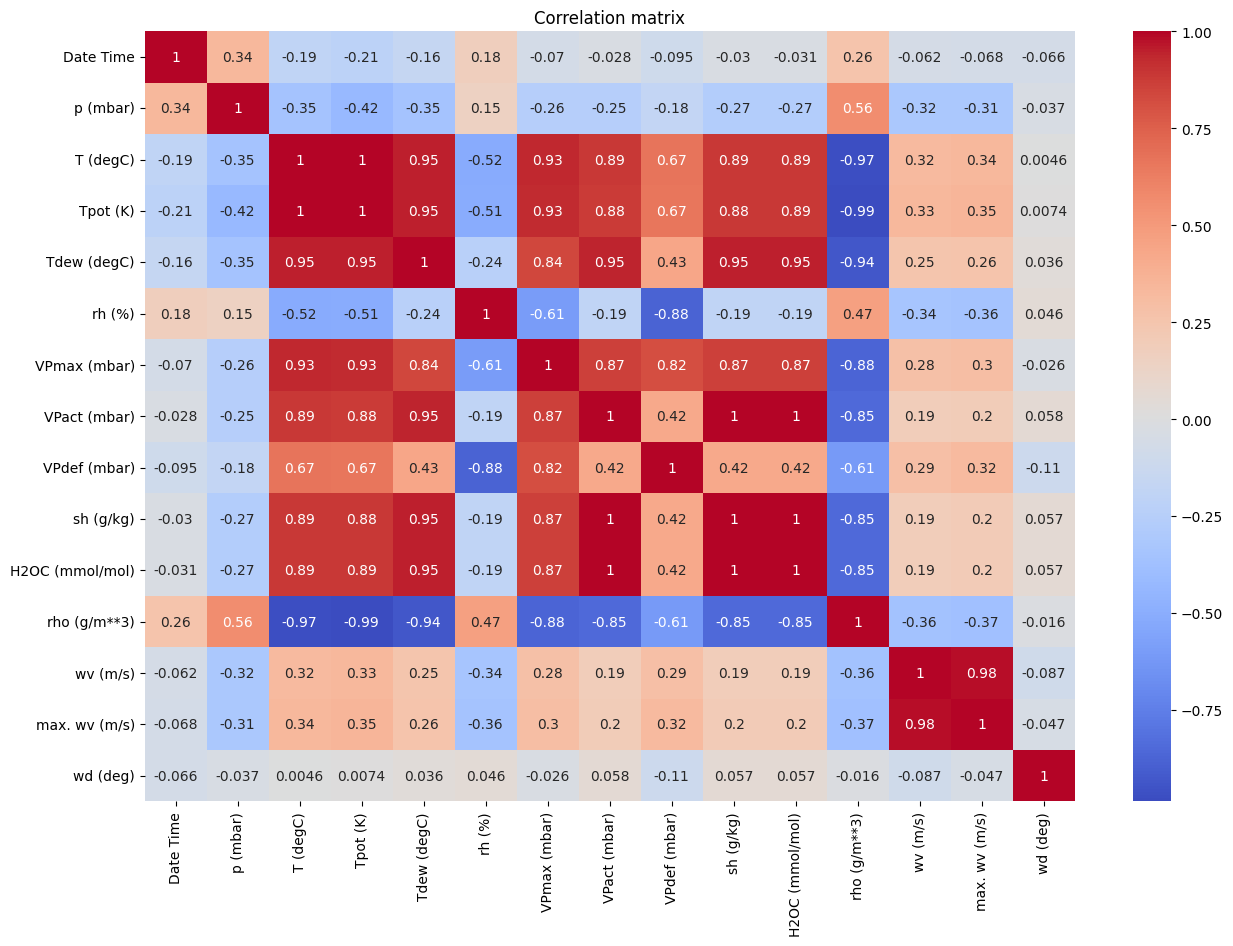

In [ ]:
#heatmap to see the correlations
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize= (15 , 10))
corr_mat= df_hourly.drop(columns=['hour_sin' , 'hour_cos' , 'doy_sin' , 'doy_cos' , 'hour' ,'day_of_year']).corr()
sns.heatmap(corr_mat , cmap='coolwarm' , annot = True)
plt.title('Correlation matrix')
plt.show()

## **droping unnessecary columns (really week correlation)**

In [ ]:
#Modification_3
#dropping the unnessecay cols that don't affect on out target like wd , wv also the highly correlated features like the same temp but with kilven
abs(corr_mat['T (degC)']).sort_values()
features_to_keep = [
        'T (degC)', 'p (mbar)', 'Tdew (degC)', 'rh (%)',
        'VPmax (mbar)', 'VPact (mbar)', 'sh (g/kg)',
        'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)',
        'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos'
    ]
df = df_hourly[features_to_keep]

## **splitting before normalization**

In [ ]:
#after preprocessing all the data (feature eng , drop unessecary cols ) except the normalizationnnn

#TEMPORAL SPLIT first
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)
test_size = len(df) - train_size - val_size

train_raw = df.iloc[:train_size].copy()
val_raw = df.iloc[train_size:train_size+val_size].copy()
test_raw = df.iloc[train_size+val_size:].copy()

print(f"Train: {train_raw.index[0]} to {train_raw.index[-1]}")
print(f"Val:   {val_raw.index[0]} to {val_raw.index[-1]}")
print(f"Test:  {test_raw.index[0]} to {test_raw.index[-1]}")


Train: 0 to 5694
Val:   5695 to 6914
Test:  6915 to 8135


## **Normalization using standard scaler but on each col separetly(better results)**

In [ ]:
# normalization
#normalizing each col separately and saving the scalers as i want to inverse the scalers while after the prediction

from sklearn.preprocessing import StandardScaler

# Initialize scalers (one per column)
scaler_dict = {}

# 5. Fit scalers ONLY on training data
for column in train_raw.columns:
    scaler = StandardScaler()
    scaler.fit(train_raw[[column]])  # ONLY TRAINING DATA!
    scaler_dict[column] = scaler

# 6. Transform all sets using TRAINING statistics
def scale_data(data_df, scaler_dict):
    scaled_df = pd.DataFrame(index=data_df.index)
    for column in data_df.columns:
        scaler = scaler_dict[column]
        scaled_df[column] = scaler.transform(data_df[[column]]).flatten()
    return scaled_df

train_scaled = scale_data(train_raw, scaler_dict)
val_scaled = scale_data(val_raw, scaler_dict)
test_scaled = scale_data(test_raw, scaler_dict)


#saving the scalers for using it in streamlit app latter
#already saved i will not run this again instead i will comment it
# import pickle
# import json
# import os

# # saving scalers for streamlit app
# # creating directory for artifacts (if it doesn't exist)
# artifacts_dir = 'preprocessing_artifacts'
# os.makedirs(artifacts_dir, exist_ok=True)

# # saving the COMPLETE scaler dictionary
# with open(f'{artifacts_dir}/scaler_dict.pkl', 'wb') as f:
#     pickle.dump(scaler_dict, f)

# print(f"✅ Saved {len(scaler_dict)} scalers to '{artifacts_dir}/scaler_dict.pkl'")





```
`# This is formatted as code`
```

### ***Verifying applying normalization approperiatly***

In [ ]:
print("\n=== VERIFICATION ===")
print("Training data after scaling (should have ~mean=0, ~std=1):")
for col in ['T (degC)' , 'rh (%)']:
    print(f"  {col}: mean={train_scaled[col].mean():.6f}, std={train_scaled[col].std():.6f}")

print("\nTest data after scaling (using TRAINING statistics):")
for col in ['T (degC)','rh (%)']:
    print(f"  {col}: mean={test_scaled[col].mean():.6f}, std={test_scaled[col].std():.6f}")
    print(f"    (Note: Not exactly 0 and 1, which is CORRECT!)")


=== VERIFICATION ===
Training data after scaling (should have ~mean=0, ~std=1):
  T (degC): mean=0.000000, std=1.000088
  rh (%): mean=-0.000000, std=1.000088

Test data after scaling (using TRAINING statistics):
  T (degC): mean=-0.445884, std=0.806335
    (Note: Not exactly 0 and 1, which is CORRECT!)
  rh (%): mean=0.484735, std=0.715919
    (Note: Not exactly 0 and 1, which is CORRECT!)


## ***Data Generation***

> (for predicting the temp for the next 12 h using the past 720 h (5 days)



In [ ]:
from tensorflow import keras
# Parameters
sequence_length = 72   #look for the previous 72 hours
sampling_rate = 1
batch_size = 128 # if i used 256 may cause potential overfitting , less genralization
delay = 12       #predicting the next 12 ones
target_col = 'T (degC)'  # Your target column


# ***converting into numy array to be appropriate for tensorflow***

In [ ]:
train_array = train_scaled.values
val_array = val_scaled.values
test_array = test_scaled.values

# Find temperature column index
target_idx = train_scaled.columns.get_loc(target_col)
print(f"Target column '{target_col}' is at index {target_idx}")

Target column 'T (degC)' is at index 0


## ***function for generation***

In [ ]:
# Function to create correctly aligned datasets
def create_multivariate_dataset(data_array, target_idx, sequence_length,
                                sampling_rate, delay, batch_size, shuffle=False):
    """
    Creates multivariate time series dataset with correct alignment

    Args:
        data_array: (n_timesteps, n_features) - ALL features
        target_idx: Index of temperature column
        sequence_length: Lookback window
        sampling_rate: How often to sample
        delay: How many steps ahead to predict
        batch_size: Batch size
        shuffle: Whether to shuffle (only for training)
    """
    # Calculate total offset
    total_offset = sequence_length + delay

    # Create targets: temperature at total_offset steps ahead
    # We need to align targets with the end of each input sequence
    targets = data_array[total_offset:, target_idx]  # Only temperature!

    # Input data: everything except the last 'delay' steps
    # (because we can't predict beyond available data)
    input_data = data_array[:-delay] if delay > 0 else data_array

    # Create dataset
    dataset = keras.utils.timeseries_dataset_from_array(
        data=input_data,
        targets=targets,
        sequence_length=sequence_length,
        sampling_rate=sampling_rate,
        sequence_stride=1,
        batch_size=batch_size,
        shuffle=shuffle,
        seed=42 if shuffle else None
    )

    return dataset

## **generation step**

In [ ]:

# Create datasets
print(f"\nCreating datasets with:")
print(f"  Sequence length: {sequence_length} steps ({sequence_length/24:.1f} days)")
print(f"  Sampling rate: {sampling_rate} (hourly samples)")
print(f"  Delay: {delay} steps ({delay/sampling_rate:.1f} hours ahead)")
print(f"  Batch size: {batch_size}")

train_dataset = create_multivariate_dataset(
    data_array=train_array,
    target_idx=target_idx,
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    delay=delay,
    batch_size=batch_size,
    shuffle=True  # Only for training
)

val_dataset = create_multivariate_dataset(
    data_array=val_array,
    target_idx=target_idx,
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    delay=delay,
    batch_size=batch_size,
    shuffle=False  # Never shuffle validation/test
)

test_dataset = create_multivariate_dataset(
    data_array=test_array,
    target_idx=target_idx,
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    delay=delay,
    batch_size=batch_size,
    shuffle=False
)


Creating datasets with:
  Sequence length: 72 steps (3.0 days)
  Sampling rate: 1 (hourly samples)
  Delay: 12 steps (12.0 hours ahead)
  Batch size: 128


In [ ]:
# 3. VERIFICATION

print("\nStep 3: Verifying datasets...")

# Check one batch from each dataset
print("\nTraining dataset:")
for batch_x, batch_y in train_dataset.take(1):
    print(f"  Batch X shape: {batch_x.shape}")  # Should be (batch, seq_len, features)
    print(f"  Batch y shape: {batch_y.shape}")  # Should be (batch,)
    print(f"  Number of features: {batch_x.shape[2]}")
    print(f"  First target (scaled temp): {batch_y[0].numpy():.3f}")

print("\nValidation dataset:")
for batch_x, batch_y in val_dataset.take(1):
    print(f"  Batch X shape: {batch_x.shape}")
    print(f"  Batch y shape: {batch_y.shape}")


Step 3: Verifying datasets...

Training dataset:
  Batch X shape: (128, 72, 14)
  Batch y shape: (128,)
  Number of features: 14
  First target (scaled temp): -0.769

Validation dataset:
  Batch X shape: (128, 72, 14)
  Batch y shape: (128,)


In [ ]:
# normalization standard scaler -> done
# outlier threshold , visulaization , nulls -> inspect , clean -> done
# splitting data (720 past , 24 future) -> done
# date generation -> done

In [ ]:
for x, y in train_dataset.take(1):
    print(x.shape)
    print(y.shape)
    print(y[:5])

(128, 72, 14)
(128,)
tf.Tensor([ 0.71749159  0.4197336  -2.64550861 -1.27398481  0.74458898], shape=(5,), dtype=float64)


In [ ]:
import tensorflow as tf
for x, y in train_dataset.take(1):
    print(tf.reduce_any(tf.math.is_nan(x)))
    print(tf.reduce_any(tf.math.is_nan(y)))
    print(tf.reduce_any(tf.math.is_inf(x)))
    print(tf.reduce_any(tf.math.is_inf(y)))


tf.Tensor(False, shape=(), dtype=bool)
tf.Tensor(False, shape=(), dtype=bool)
tf.Tensor(False, shape=(), dtype=bool)
tf.Tensor(False, shape=(), dtype=bool)


In [ ]:
def forecast_data(model, data):
    preds = []
    trues = []
    for batch_x, batch_y in data:
        batch_pred = model.predict(batch_x)
        preds.extend(batch_pred.flatten())
        trues.extend(batch_y.numpy().flatten())
    return np.array(preds), np.array(trues)

# **GRU Model with BatchNormalization**

In [ ]:
import tensorflow as tf
from tensorflow import keras

for batch_x, _ in train_dataset.take(1):
    input_shape = batch_x.shape[1:]  # (timesteps, features)

print("Input shape:", input_shape)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

gru_model = keras.Sequential([
    keras.layers.GRU(
        64,
        input_shape=input_shape,
        dropout=0.3,
        recurrent_dropout=0.2
    ),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1)  # Regression output
])

gru_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

gru_model.summary()

history = gru_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stopping],
    verbose=1
)

gru_preds_scaled, gru_true_scaled = forecast_data(
    gru_model,
    test_dataset
)

# Inverse scaling
gru_preds = scaler.inverse_transform(
    gru_preds_scaled.reshape(-1, 1)
).flatten()

gru_true = scaler.inverse_transform(
    gru_true_scaled.reshape(-1, 1)
).flatten()

print("First 5 predictions:", gru_preds[:5])
print("First 5 actual values:", gru_true[:5])


Input shape: (72, 14)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 64)             │        15,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,473 (68.25 KB)

 Trainable params: 17,473 (68.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 284ms/step - loss: 0.7601 - mae: 0.6393 - val_loss: 0.2721 - val_mae: 0.3949
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 188ms/step - loss: 0.3543 - mae: 0.4484 - val_loss: 0.2402 - val_mae: 0.3654
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 207ms/step - loss: 0.3464 - mae: 0.4311 - val_loss: 0.2271 - val_mae: 0.3438
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 275ms/step - loss: 0.3085 - mae: 0.4032 - val_loss: 0.2304 - val_mae: 0.3673
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 253ms/step - loss: 0.3021 - mae: 0.4028 - val_loss: 0.2322 - val_mae: 0.3714
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 207ms/step - loss: 0.2803 - mae: 0.3866 - val_loss: 0.2185 - val_mae: 0.3496
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 188ms/step - loss: 0.2814 - mae: 0.3862 - val_loss: 0.2095 - val_mae: 0.3494
Epoch 8/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 204ms/step - loss: 0.2719 - mae: 0.3782 - val_loss: 0.2093 - val_mae: 0.3580
Epoch 9/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 203ms/step 

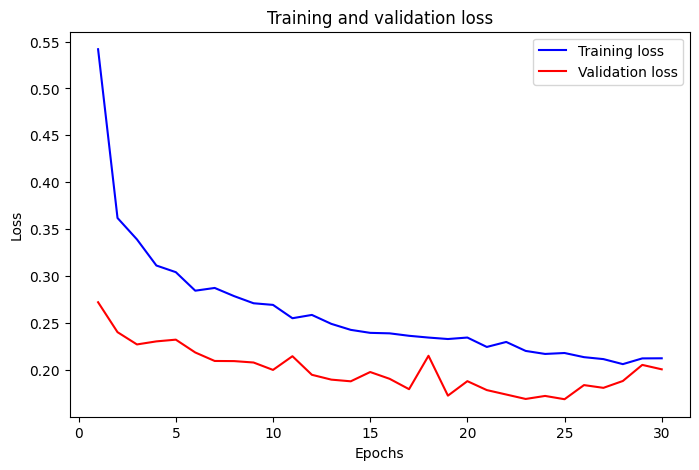

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

In [ ]:
gru_model.save("gru_temperature_model.keras")